# ASTE

In [ ]:
import yaml
from pathlib import Path

with open('config.yaml') as _f:
    cfg = yaml.safe_load(_f)

DATA_DIR = Path(cfg['output']['data_dir']) / 'reanalysis'
DATA_DIR.mkdir(parents=True, exist_ok=True)

# subsetting by location (might get data that isnt valid ocean)

In [ ]:
import matplotlib.pyplot as plt
import xarray as xr
from xmitgcm import llcreader
import numpy as np
from dask.distributed import Client, LocalCluster
import pandas as pd

target_lat = 71
target_lon = -54
target_depth = 50.0

print(f"Target: Lat={target_lat}°N, Lon={target_lon}°W, Depth={target_depth}m")

try:
    client.close()
    cluster.close()
except:
    pass

cluster = LocalCluster()
client = Client(cluster)
print(f"Dask dashboard URL: {cluster.dashboard_link}")

print("Loading ASTE dataset...")
aste = llcreader.CRIOSPortalASTE270Model()
ds = aste.get_dataset(varnames=['THETA', 'Depth'])
ds = ds.rename({'face': 'tile'})

cds = ds.coords.to_dataset().reset_coords()
ds = ds.reset_coords(drop=True)

print(f"Dimensions: {ds.dims}")
print(f"Time range: {ds.time.values[0]} to {ds.time.values[-1]}")

xc = cds['XC'].values
yc = cds['YC'].values
z = cds['Z'].values

k_index_values = pd.DataFrame({'k_index': range(len(z)), 'depth_m': z})
k_csv_path = DATA_DIR / 'ASTE_k_index_to_depth.csv'
k_index_values.to_csv(k_csv_path, index=False)
print(f"Saved k-index mapping to {k_csv_path}")

dist = (xc - target_lon)**2 + (yc - target_lat)**2
valid_mask = ~(np.isnan(xc) | np.isnan(yc))
dist_masked = np.where(valid_mask, dist, np.inf)
min_idx = np.nanargmin(dist_masked)
tile_idx, j_idx, i_idx = np.unravel_index(min_idx, dist.shape)

selected_lat = yc[tile_idx, j_idx, i_idx]
selected_lon = xc[tile_idx, j_idx, i_idx]
print(f"Selected: Tile={tile_idx}, i={i_idx}, j={j_idx}, Lat={selected_lat:.3f}°N, Lon={selected_lon:.3f}°E")

print("Extracting THETA timeseries...")
theta_ts = ds[['THETA']].isel(tile=int(tile_idx), j=int(j_idx), i=int(i_idx))
theta_ts = theta_ts.assign_coords(Depth=cds['Depth'].isel(tile=int(tile_idx), j=int(j_idx), i=int(i_idx)))
theta_ts = theta_ts.assign_coords({'lat': selected_lat, 'lon': selected_lon})

out_path = DATA_DIR / 'ASTE_theta_timeseries.nc'
theta_ts.to_netcdf(out_path)
print(f"Saved to {out_path}")

Loading ASTE dataset...

Coordinates for tile=2, i=66, j=266: Lat=70.92487841645145, Lon=-55.13925403141961


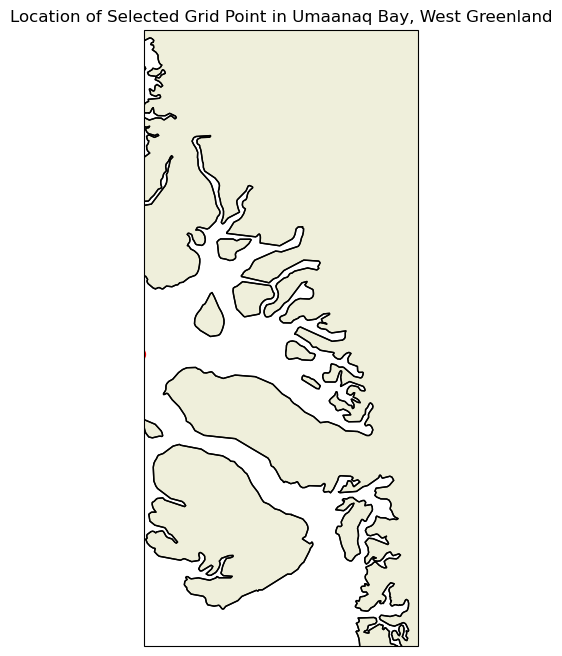

In [11]:
import matplotlib.pyplot as plt
import xarray as xr
from xmitgcm import llcreader
import numpy as np
from dask.distributed import Client, LocalCluster
import pandas as pd

# --- 3. Load ASTE Dataset ---
print("Loading ASTE dataset...")
aste = llcreader.CRIOSPortalASTE270Model()
ds = aste.get_dataset(varnames=['THETA', 'Depth'])
        
# Rename face to tile (ASTE convention)
ds = ds.rename({'face': 'tile'})

# Split coordinates and data
cds = ds.coords.to_dataset().reset_coords()
ds = ds.reset_coords(drop=True)

# get lat lon of tile=2, i=64, j=265
tile = 2
i = 66
j = 266
lat = cds['YC'].isel(tile=tile, j=j, i=i).values
lon = cds['XC'].isel(tile=tile, j=j, i=i).values
print(f"\nCoordinates for tile={tile}, i={i}, j={j}: Lat={lat}, Lon={lon}")
# print if there is valid THETA data at this point
theta_data = ds['THETA'].isel(tile=tile, j=j, i=i, k=1, time=5).values
if np.all(np.isnan(theta_data)):
    print("No valid THETA data at this point.")

# plot coordinates on cartopy map of umaanaq bay in west greenland using coastline (110m) feature
import cartopy.crs as ccrs
import cartopy.feature as cfeature
central_lon = lon
central_lat = lat
projection = ccrs.NorthPolarStereo(central_longitude=central_lon, true_scale_latitude=central_lat)

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=projection)
ax.set_extent([-55, -50, 69, 73], crs=ccrs.PlateCarree())
resol = '10m' # Requires cartopy data download on first run
land_feature = cfeature.NaturalEarthFeature('physical', 'land', scale=resol,
                                            edgecolor='black', facecolor=cfeature.COLORS['land'])
ax.plot(lon, lat, marker='o', color='red', markersize=10, transform=ccrs.PlateCarree())
ax.add_feature(land_feature)
ax.coastlines(resolution=resol)
ax.set_title('Location of Selected Grid Point in Umaanaq Bay, West Greenland')
plt.show()

# Updated ASTE extraction by subsetting with known correct indicies

In [ ]:
# import matplotlib.pyplot as plt
# import xarray as xr
# from xmitgcm import llcreader
# import numpy as np
# from dask.distributed import Client, LocalCluster
# import pandas as pd

# # --- 1. Fixed Location ---
# tile_idx = 2
# i_idx = 66
# j_idx = 266

# print(f"Extracting THETA at: tile={tile_idx}, i={i_idx}, j={j_idx}")

# # --- 2. Setup Dask (with cleanup) ---
# # Close any existing clusters first
# try:
#     client.close()
#     cluster.close()
# except:
#     pass

# cluster = LocalCluster(n_workers=2, threads_per_worker=4, memory_limit='4GB')
# client = Client(cluster)
# print(f"Dask dashboard URL: {cluster.dashboard_link}")

# # --- 3. Load ASTE Dataset ---
# print("Loading ASTE dataset...")
# aste = llcreader.CRIOSPortalASTE270Model()
# ds = aste.get_dataset(varnames=['THETA', 'Depth'])
        
# # Rename face to tile (ASTE convention)
# ds = ds.rename({'face': 'tile'})

# # Split coordinates and data
# cds = ds.coords.to_dataset().reset_coords()
# ds = ds.reset_coords(drop=True)

# print("Dataset loaded successfully")
# print(f"Dimensions: {ds.dims}")
# print(f"Time range: {ds.time.values[0]} to {ds.time.values[-1]}")

# theta_only = ds[['THETA']]

# # --- 4. Get coordinates for selected location ---
# z = cds['Z'].values
# selected_lat = cds['YC'].isel(tile=tile_idx, j=j_idx, i=i_idx).values
# selected_lon = cds['XC'].isel(tile=tile_idx, j=j_idx, i=i_idx).values

# # using z values match them to k index values as save as a csv for future reference
# k_index_values = pd.DataFrame({
#     'k_index': range(len(z)),
#     'depth_m': z
# })
# k_index_values.to_csv('ASTE_k_index_to_depth.csv', index=False)
# print(f"\nSaved k-index to depth mapping to 'ASTE_k_index_to_depth.csv'")

# print(f"\nSelected location:")
# print(f"  Tile={tile_idx}, i={i_idx}, j={j_idx}")
# print(f"  Lat={selected_lat:.3f}°N")
# print(f"  Lon={selected_lon:.3f}°E ({selected_lon-360:.3f}°W)")

# # Check if ocean point
# hfac = cds['hFacC'].isel(tile=tile_idx, j=j_idx, i=i_idx).values
# print(f"  Ocean fractions (hFacC): {hfac}")

# # --- 5. Extract THETA Timeseries at all depths ---
# print("\nExtracting THETA timeseries at all depths...")
# print(f"Selecting: tile={tile_idx}, j={j_idx}, i={i_idx}")

# # Use integer indexing - select THETA and keep all k levels
# theta_ts = ds[['THETA']].isel(tile=int(tile_idx), j=int(j_idx), i=int(i_idx))

# # Add Depth coordinate from cds (actual depths in meters)
# theta_ts = theta_ts.assign_coords(Depth=cds['Depth'].isel(tile=int(tile_idx), j=int(j_idx), i=int(i_idx)))

# # Export to netcdf
# print("Exporting theta timeseries to netCDF...")
# # Add lat/lon coordinates
# theta_ts = theta_ts.assign_coords({
#     'lat': selected_lat,
#     'lon': selected_lon
# })

# print("Computing data into memory and exporting to netCDF...")
# theta_ts_local = theta_ts.compute()
# theta_ts_local.to_netcdf('ASTE_theta_timeseries_updated.nc')

# print(f"Theta timeseries exported to 'ASTE_theta_timeseries_updated.nc'")
# print(f"Included variables: {list(theta_ts_local.data_vars)}")
# print(f"Included coordinates: {list(theta_ts_local.coords)}")
# print(f"Depth coordinate shape: {theta_ts_local.Depth.shape}")
# print(f"Depth range: {theta_ts_local.Depth.values.min():.1f}m to {theta_ts_local.Depth.values.max():.1f}m")

In [ ]:
import matplotlib.pyplot as plt
import xarray as xr
from xmitgcm import llcreader
import numpy as np
from dask.distributed import Client, LocalCluster
import pandas as pd
import time

# --- 1. Settings & Location ---
# Global indices for the llcreader/aggregated dataset
tile_idx = 2
i_idx = 66
j_idx = 266
output_filename = 'ASTE_theta_timeseries_optimized.nc'

print(f"Extracting THETA at: tile={tile_idx}, i={i_idx}, j={j_idx}")

# --- 2. Setup Optimized Dask Client ---
# Using a "thin" client reduces network overhead for single-point reads.
try:
    client.close()
    cluster.close()
except:
    pass

cluster = LocalCluster(n_workers=2, threads_per_worker=4, memory_limit='4GB')
client = Client(cluster)
print(f"Dask dashboard URL: {cluster.dashboard_link}")

# --- 3. Load ASTE Dataset ---
print("Loading ASTE dataset (Lazy)...")
aste = llcreader.CRIOSPortalASTE270Model()
# Only load THETA to keep the graph small.
ds = aste.get_dataset(varnames=['THETA'])
ds = ds.rename({'face': 'tile'})

# Get coordinates and depth metadata
cds = ds.coords.to_dataset().reset_coords()
z_levels = cds['Z'].values
lat = float(cds['YC'].isel(tile=tile_idx, j=j_idx, i=i_idx))
lon = float(cds['XC'].isel(tile=tile_idx, j=j_idx, i=i_idx))
depth_val = float(cds['Depth'].isel(tile=tile_idx, j=j_idx, i=i_idx))
hfac = float(cds['hFacC'].isel(tile=tile_idx, j=j_idx, i=i_idx, k=0))

print(f"Location Verified: {lat:.3f}N, {lon:.3f}E | Max Depth: {depth_val:.1f}m")
print(f"Ocean Fraction (hFacC): {hfac} (1.0 = Water, 0.0 = Land)")

# --- 4. Optimized Extraction ---
print("\nStarting data extraction. This requires many small remote reads...")
start_time = time.time()

# Step 1: Isolate the single point time-series lazily
# This creates a Dask graph for just the column you need.
theta_ts_lazy = ds['THETA'].isel(tile=tile_idx, i=i_idx, j=j_idx)

# Step 2: COMPUTE into memory.
# This is the 'Speed Trick'. It fetches the data and brings it into local RAM 
# before attempting to write to a NetCDF file.
print("Fetching data from remote server to local RAM...")
theta_ts_local = theta_ts_lazy.compute()

elapsed = (time.time() - start_time) / 60
print(f"Extraction complete in {elapsed:.2f} minutes.")

# --- 5. Package and Save ---
print("Packaging metadata and saving to NetCDF...")

# Create a clean dataset from the computed data
final_ds = theta_ts_local.to_dataset(name='THETA')
final_ds = final_ds.assign_coords({
    'lat': lat,
    'lon': lon,
    'Depth_m': (('k'), cds['K'].isel(tile=tile_idx, j=j_idx, i=i_idx).values),
    'Z_level': (('k'), z_levels)
})

# Add helpful attributes
final_ds.attrs['description'] = f"ASTE THETA Timeseries at West Greenland"
final_ds.attrs['global_indices'] = f"tile={tile_idx}, i={i_idx}, j={j_idx}"

# Save to disk - this will now be nearly instantaneous
final_ds.to_netcdf(output_filename)

print(f"Success! File saved as: {output_filename}")

# --- 6. Cleanup ---
client.close()
cluster.close()

Extracting THETA at: tile=2, i=66, j=266
Dask dashboard URL: http://127.0.0.1:8787/status
Loading ASTE dataset (Lazy)...
Location Verified: 70.925N, -55.139E | Max Depth: 513.3m
Ocean Fraction (hFacC): 1.0 (1.0 = Water, 0.0 = Land)

Starting data extraction. This requires many small remote reads...
Fetching data from remote server to local RAM...
Extraction complete in 401.03 minutes.
Packaging metadata and saving to NetCDF...


ValueError: Variable 'Depth_m': Could not convert tuple of form (dims, data[, attrs, encoding]): ('k', array(513.26)) to Variable.

In [ ]:
final_ds = theta_ts_local.to_dataset(name='THETA')
final_ds = final_ds.assign_coords({'lat': lat, 'lon': lon, 'Depth_m': (('k'), z_levels)})
final_ds.attrs['description'] = "ASTE THETA Timeseries at West Greenland"
final_ds.attrs['global_indices'] = f"tile={tile_idx}, i={i_idx}, j={j_idx}"

out_path = DATA_DIR / 'ASTE_theta_timeseries_optimized.nc'
final_ds.to_netcdf(out_path)
print(f"Saved to {out_path}")

client.close()
cluster.close()

Dataset structure:
<xarray.Dataset> Size: 45kB
Dimensions:    (k: 50, time: 193)
Coordinates: (12/23)
    tile       int64 8B ...
    i          int64 8B ...
    j          int64 8B ...
  * k          (k) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    niter      (time) int64 2kB ...
  * time       (time) datetime64[ns] 2kB 2002-02-01 ... 2018-01-01T01:20:00
    ...         ...
    maskC      (k) float64 400B ...
    maskCtrlC  (k) float64 400B ...
    maskInC    float64 8B ...
    lat        float64 8B ...
    lon        float64 8B ...
    Depth_m    (k) float64 400B ...
Data variables:
    THETA      (time, k) float32 39kB ...
Attributes:
    description:     ASTE THETA Timeseries at West Greenland
    global_indices:  tile=2, i=66, j=266

Depth range: -5906.2m to -5.0m

Number of depth levels used (200-500m): 6


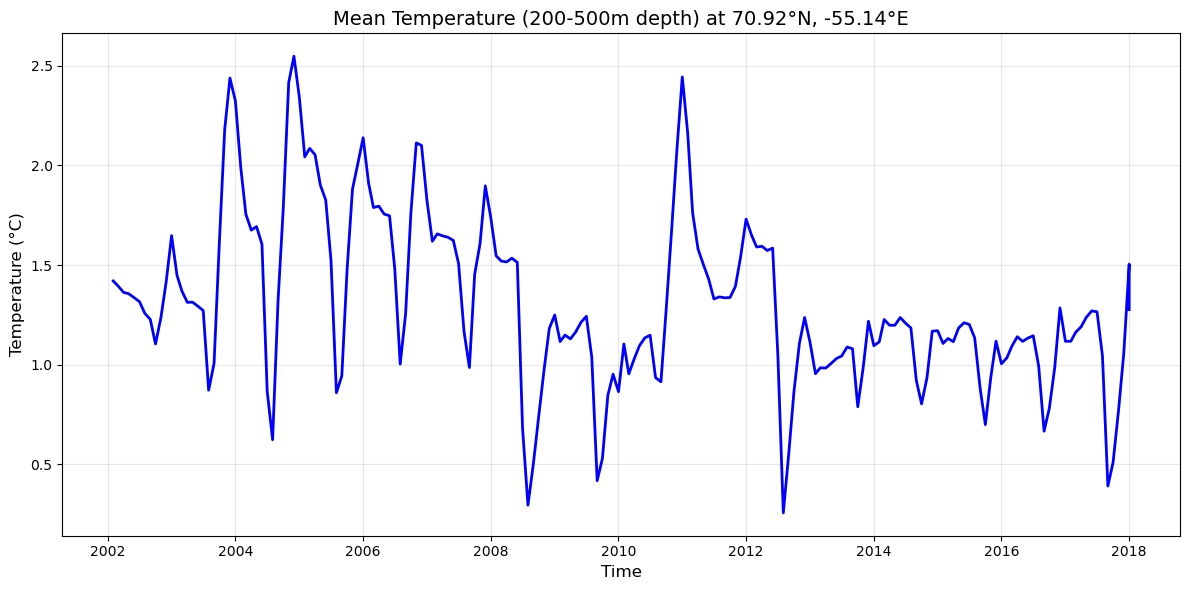

In [24]:
# Open the exported dataset and plot mean temperature between 200-500m
import xarray as xr
import matplotlib.pyplot as plt

# Load the dataset
ds = xr.open_dataset('ASTE_theta_timeseries_optimized.nc')
print("Dataset structure:")
print(ds)
print(f"\nDepth range: {ds.Depth_m.values.min():.1f}m to {ds.Depth_m.values.max():.1f}m")

# Select depths between 200m and 500m (depths are negative)
mean_temp_200_500m = ds['THETA'].where((ds.Depth_m <= -200) & (ds.Depth_m >= -500), drop=True).mean(dim='k')

print(f"\nNumber of depth levels used (200-500m): {ds['THETA'].where((ds.Depth_m <= -200) & (ds.Depth_m >= -500), drop=True).sizes['k']}")

# Plot the timeseries
fig, ax = plt.subplots(figsize=(12, 6))
mean_temp_200_500m.plot(ax=ax, color='blue', linewidth=2)
ax.set_title(f'Mean Temperature (200-500m depth) at {ds.lat:.2f}°N, {ds.lon:.2f}°E', fontsize=14)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


(-600.0, -5.0)

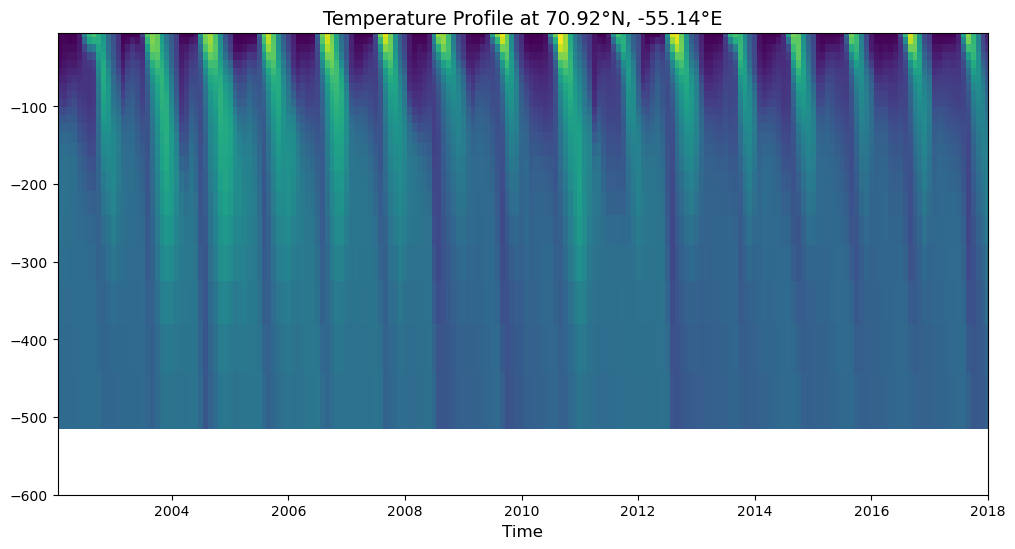

In [30]:
# plot imshow or pcolormesh of temperature vs depth and time (THETA) and Depth_m
fig, ax = plt.subplots(figsize=(12, 6))
time_vals = ds['time'].values
depth_vals = ds['Depth_m'].values
temp_vals = ds['THETA'].values.T  # Transpose to have depth on y-axis
pcm = ax.pcolormesh(time_vals, depth_vals, temp_vals, shading='auto', cmap='viridis')
ax.set_title(f'Temperature Profile at {ds.lat:.2f}°N, {ds.lon:.2f}°E', fontsize=14)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylim(-600, depth_vals.max())